In [1]:
# --- make parent folder importable ---
import sys
# --- usual imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from scipy.integrate import quad
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, average_precision_score
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from scipy.stats import gmean, linregress, norm, beta, uniform, lognorm
from scipy.integrate import simpson, trapezoid
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy.integrate import simpson
from scipy import stats
import glob
import os
import math
import re
import csv
from tqdm import tqdm
import time
import joblib
from joblib import Parallel, delayed, parallel_backend
import multiprocessing
import pickle
import random
import json
import LoF_func

## Get probabilty of misannotation and store the likelihoods

In [2]:
# Values of parameters to be passed to calculate the Likelihood
LoF_filename  = "../Data/gnomad_lof_full.txt.gz"
outdir_pnull  = "Pnull_values"
pkl_LL_folder = "/n/data2/hms/dbmi/sunyaev/lab/pkar/likelihood_s_anc/"

In [ ]:
demography    = "NFE"
SFS_file      = f"/n/data2/hms/dbmi/sunyaev/lab/pkar/demography_SFS/SFS_{demography}.pkl"
LoF_func.likelihood_LoF(LoF_filename, demography, SFS_file, outdir_pnull, pkl_LL_folder)

Optimization terminated successfully.
         Current function value: 676447.773354
         Iterations: 45
         Function evaluations: 81

Final Estimates:
pnull: {'stop_gained': np.float64(0.024311906124723823), 'splice_donor_variant': np.float64(0.06448659907179272), 'splice_acceptor_variant': np.float64(0.08918696954315614)}
Calculated likelihood for NFE demography


In [3]:
demography    = "SAS"
SFS_file      = f"/n/data2/hms/dbmi/sunyaev/lab/pkar/demography_SFS/SFS_{demography}.pkl"
LoF_func.likelihood_LoF(LoF_filename, demography, SFS_file, outdir_pnull, pkl_LL_folder)

Optimization terminated successfully.
         Current function value: 230561.692209
         Iterations: 69
         Function evaluations: 121

Final Estimates:
pnull: {'stop_gained': np.float64(0.01099141303795595), 'splice_donor_variant': np.float64(0.018068938702715778), 'splice_acceptor_variant': np.float64(0.04628074298562458)}
Calculated likelihood for SAS demography


In [4]:
demography    = "EAS"
SFS_file      = f"/n/data2/hms/dbmi/sunyaev/lab/pkar/demography_SFS/SFS_{demography}.pkl"
LoF_func.likelihood_LoF(LoF_filename, demography, SFS_file, outdir_pnull, pkl_LL_folder)

Optimization terminated successfully.
         Current function value: 121050.675409
         Iterations: 106
         Function evaluations: 188

Final Estimates:
pnull: {'stop_gained': np.float64(0.002050691408617394), 'splice_donor_variant': np.float64(0.015111956682431357), 'splice_acceptor_variant': np.float64(0.016176173480145283)}
Calculated likelihood for EAS demography


In [6]:
demography    = "AFR"
SFS_file      = f"/n/data2/hms/dbmi/sunyaev/lab/pkar/demography_SFS/SFS_{demography}.pkl"
LoF_func.likelihood_LoF(LoF_filename, demography, SFS_file, outdir_pnull, pkl_LL_folder)

Optimization terminated successfully.
         Current function value: 119236.169475
         Iterations: 73
         Function evaluations: 129

Final Estimates:
pnull: {'stop_gained': np.float64(0.003103037260014051), 'splice_donor_variant': np.float64(0.015640338789995083), 'splice_acceptor_variant': np.float64(0.025254513605491788)}
Calculated likelihood for AFR demography


In [7]:
demography    = "AMR"
SFS_file      = f"/n/data2/hms/dbmi/sunyaev/lab/pkar/demography_SFS/SFS_{demography}.pkl"
LoF_func.likelihood_LoF(LoF_filename, demography, SFS_file, outdir_pnull, pkl_LL_folder)

Optimization terminated successfully.
         Current function value: 130572.766538
         Iterations: 64
         Function evaluations: 113

Final Estimates:
pnull: {'stop_gained': np.float64(0.0029844396921357872), 'splice_donor_variant': np.float64(0.02132204842588789), 'splice_acceptor_variant': np.float64(0.04263778535573745)}
Calculated likelihood for AMR demography


In [8]:
demography    = "FIN"
SFS_file      = f"/n/data2/hms/dbmi/sunyaev/lab/pkar/demography_SFS/SFS_{demography}.pkl"
LoF_func.likelihood_LoF(LoF_filename, demography, SFS_file, outdir_pnull, pkl_LL_folder)

Optimization terminated successfully.
         Current function value: 80849.741994
         Iterations: 118
         Function evaluations: 201

Final Estimates:
pnull: {'stop_gained': np.float64(0.0004645581953997368), 'splice_donor_variant': np.float64(1e-10), 'splice_acceptor_variant': np.float64(1e-10)}
Calculated likelihood for FIN demography


## Get the likelihood per gene
We assume each demography as independent. Total Likelihood = Product of likelihood of each demography

In [2]:
demographies = ["NFE", "SAS", "EAS", "AFR", "AMR", "FIN"]
pkl_LL_folder = "/n/data2/hms/dbmi/sunyaev/lab/pkar/likelihood_s_anc/"
LL_dict = LoF_func.get_LL_estimates(demographies, pkl_LL_folder)

## Get Posterior estimates
We use a lognormal distribution as the prior. 
The prior means from Genebayes are used as the mean while variance is a global parameter = 0.5 (default)

In [3]:
df_genebayes = pd.read_csv("../Data/LoF/GeneBayes.txt", sep="\t")
post_dict = LoF_func.compute_LPs(LL_dict, df_genebayes)

## Infer various summary statistics from Posterior and likelihood

In [4]:
df_summary = LoF_func.infer_summary_stats(LL_dict, post_dict)

17052 genes were summarized


In [5]:
df_gene_names = pd.read_csv("../Data/ENS2Gene.txt", sep="\t", header=None, names=["gene_id", "gene_name"])
df_summary = df_summary.merge(df_gene_names, on = "gene_id", how = "left")

In [6]:
# df_summary[["gene_id", "Posterior_mean", "Posterior_CI5_lower", "Posterior_CI10_lower", "Posterior_CI5_upper", "Posterior_CI10_upper", "gene_name"]].to_csv("LoF_s_het.txt.gz", sep="\t", index=False, compression="gzip")

# Benchmarking

In [6]:
# merge with GeneBayes for comparison
df_summary = df_summary.merge(df_genebayes, left_on = 'gene_id', right_on = 'ensg', how='left')
df_summary = df_summary.drop(['ensg', 'hgnc'], axis = 1)

In [7]:
df_s_het_Weghorn = pd.read_csv("../Data/LoF/Weghorn_MBE_s_het.txt", sep="\t")
# merge with s_het (Weghorn et al., MBE, 2019) for comparison
df_summary = df_summary.merge(df_s_het_Weghorn[["Gene", "s_het_drift", "low_drift"]], left_on = 'gene_name', right_on = 'Gene', how='left')
df_summary = df_summary.drop(['Gene'], axis = 1)

In [8]:
df_s_het_Agarwal = pd.read_csv("../Data/LoF/Agarwal_et_al_elife.txt", sep="\t")
# merge with s_het (Agarwal et al., eLife, 2023) for comparison
df_summary = df_summary.merge(df_s_het_Agarwal[["Gene", "log10_ci_low", "log10_map"]], left_on = 'gene_name', right_on = 'Gene', how='left')
df_summary = df_summary.drop(['Gene'], axis = 1)

In [9]:
df_s_het_Sun = pd.read_excel("../Data/LoF/Regeneron_2024_shet.xlsx", sheet_name = "table_s2")
df_summary = df_summary.merge(df_s_het_Sun[["GeneId", "mean", "shet_lower", "shet_upper"]], left_on = 'gene_id', right_on = 'GeneId', how='left')
df_summary = df_summary.drop(['GeneId'], axis = 1)

In [10]:
df_s_het_LOEUF = pd.read_csv("../Data/LoF/all_genes_scores.tsv", sep = "\t")
df_summary = df_summary.merge(df_s_het_LOEUF[["gene_symbol", "LOEUF"]], left_on = 'gene_name', right_on = 'gene_symbol', how='left')
df_summary = df_summary.drop(['gene_symbol'], axis = 1)
df_summary["LOEUF"] = -df_summary["LOEUF"]

In [11]:
df_summary = df_summary.dropna()
df_summary

,gene_id,L_mean,L_median,L_mode,Posterior_mean,Posterior_median,Posterior_mode,LL_CI10_lower,LL_CI10_upper,Posterior_CI10_lower,...,post_lower_95,post_upper_95,s_het_drift,low_drift,log10_ci_low,log10_map,mean,shet_lower,shet_upper,LOEUF
0,ENSG00000000419,0.018001,0.017721,0.017079,0.018017,0.017721,0.017079,0.010569,0.027598,0.010967,...,0.006617,0.036341,0.019605,0.000889,-5.555776,-1.713579,0.024759,0.019870,0.030884,-1.083280
1,ENSG00000000457,0.024611,0.024705,0.022947,0.023383,0.022947,0.021314,0.016460,0.035736,0.015864,...,0.005009,0.032754,0.012033,0.000889,-4.870693,-1.906930,0.025370,0.021197,0.030500,-0.615923
2,ENSG00000000460,0.006745,0.006541,0.006304,0.006514,0.006541,0.006304,0.003760,0.010967,0.003623,...,0.000714,0.006110,0.004307,0.000889,-6.096414,-3.610349,0.004463,0.004158,0.004793,-0.854321
3,ENSG00000000938,0.051527,0.048013,0.037080,0.048617,0.046273,0.035736,0.027598,0.089931,0.026598,...,0.019626,0.064758,0.101739,0.002812,-1.409306,-0.867088,0.062363,0.046726,0.083431,-0.530390
4,ENSG00000000971,0.045243,0.044596,0.041422,0.044392,0.044596,0.041422,0.031990,0.064509,0.031990,...,0.015950,0.055968,0.095456,0.008891,-1.910274,-1.556715,0.050856,0.041791,0.061753,-0.515265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16871,ENSG00000271303,0.003168,0.000925,0.000001,0.005607,0.004868,0.002083,0.000002,0.012712,0.000891,...,0.000485,0.016323,0.019762,0.000889,-5.389634,-0.908054,0.011281,0.008739,0.014534,-2.483315
16877,ENSG00000272047,0.002707,0.000714,0.000001,0.005906,0.005241,0.003244,0.000002,0.010967,0.001154,...,0.000226,0.010293,0.008263,0.000889,-6.195536,-4.071653,0.007206,0.005738,0.009045,-2.221299
16878,ENSG00000272325,0.043815,0.034441,0.000001,0.048217,0.039921,0.027598,0.013686,0.108160,0.017721,...,0.020518,0.124946,0.110970,0.000889,-2.438083,-0.805617,0.041067,0.025993,0.064295,-0.585651
16879,ENSG00000272333,0.654754,0.613162,0.509818,0.594324,0.569523,0.491341,0.365701,1.148472,0.352447,...,0.245340,0.797261,0.176555,0.028117,-0.981334,-0.594500,0.723785,0.489208,0.969884,-0.102882


In [12]:
# Benchmark dataset
with open("../Data/LoF/gene_lists.pkl", "rb") as f:
    gene_lists = pickle.load(f)

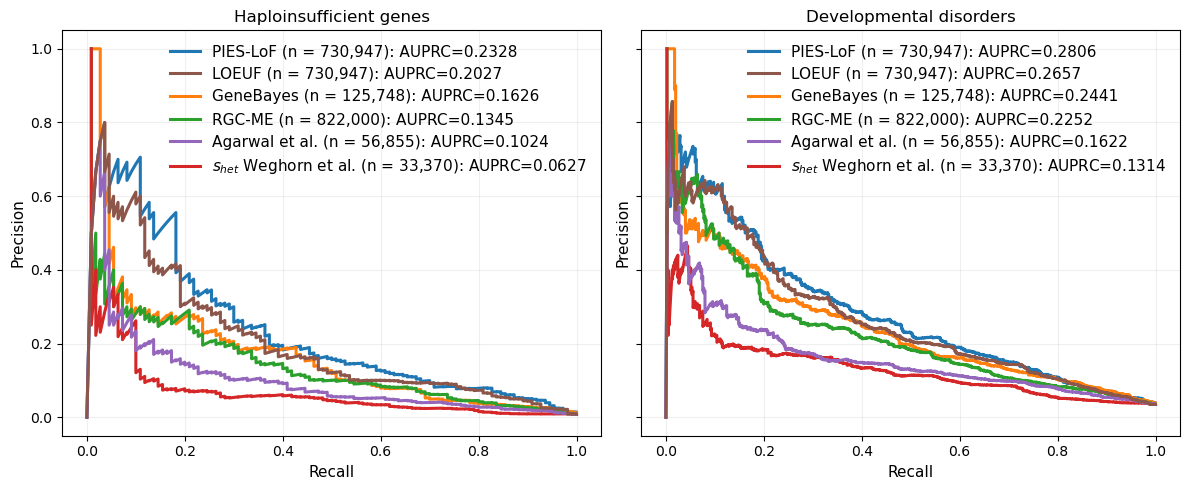

In [13]:
def precision_recall_ranked(ranked_ids, benchmark_ids):
    """
    ranked_ids: 1D array/list of ranked gene IDs (the universe)
    benchmark_ids: iterable of benchmark gene IDs (positives, may include IDs not in universe)

    Returns precision, recall computed on positives that are present in the universe.
    """
    ranked_ids = np.asarray(ranked_ids)
    bench = set(benchmark_ids)

    is_pos = np.fromiter((g in bench for g in ranked_ids), dtype=bool, count=len(ranked_ids))

    TP = np.cumsum(is_pos)
    FP = np.cumsum(~is_pos)

    # Only positives that can possibly be recovered
    P = is_pos.sum()
    if P == 0:
        # No overlap: undefined recall curve; return empty arrays (or zeros)
        return np.array([]), np.array([]), 0, 0

    FN = P - TP
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    return precision, recall, P, len(bench)

MA_genes = gene_lists['MacArthurHIgenes']
NDD600 = gene_lists['NDD600']

def plot_benchmarks(df_sfac, df_labels, bench_arr, labs, method_labels, filename=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    axes = axes.flatten()

    universe = df_sfac["gene_id"].to_numpy()

    for idx, bench in enumerate(bench_arr):
        legend_entries = []  # (auc, handle, label)

        for c in df_labels:
            df_sort = df_sfac.sort_values(by=c, ascending=False)
            ranked = df_sort["gene_id"].to_numpy()

            precision, recall, P_in_universe, P_total = precision_recall_ranked(ranked, bench)

            if precision.size == 0:
                continue

            auc = np.trapezoid(precision, recall)

            line, = axes[idx].plot(
                recall, precision, lw = 2.2,
                label=f"{method_labels[c]}: AUPRC={auc:.4f}"
            )

            legend_entries.append(
                (auc, line, f"{method_labels[c]}: AUPRC={auc:.4f}")
            )

        # ---- sort legend by AUPRC (descending) ----
        legend_entries.sort(key=lambda x: x[0], reverse=True)

        if legend_entries:
            handles = [e[1] for e in legend_entries]
            labels  = [e[2] for e in legend_entries]
            axes[idx].legend(handles, labels, fontsize=11, frameon = False)
        
        axes[idx].set_xlabel("Recall", fontsize = 11)
        axes[idx].set_ylabel("Precision", fontsize = 11)
        axes[idx].set_title(f"{labs[idx]}", fontsize = 12)
        axes[idx].grid(True, alpha=0.2, lw=0.8)

    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, dpi=300)
    plt.show()

labs = ["Haploinsufficient genes",
        "Developmental disorders"]

bench_arr = [MA_genes, 
             NDD600]

df_labels = ["Posterior_CI10_lower",
             "post_lower_95",
             "shet_lower",
             "low_drift",
             "log10_ci_low",
             "LOEUF"
             ]

method_labels = {"post_lower_95": "GeneBayes (n = 125,748)", "Posterior_CI10_lower": "PIES-LoF (n = 730,947)", "LOEUF": "LOEUF (n = 730,947)",
                 "low_drift": r"$s_{het}$ Weghorn et al. (n = 33,370)", "log10_ci_low": "Agarwal et al. (n = 56,855)", "shet_lower": "RGC-ME (n = 822,000)"}

plot_benchmarks(df_summary, df_labels, bench_arr=bench_arr, labs=labs, method_labels = method_labels, filename="../Figures/benchmark_LoF.svg")

### Obtain p-value for the difference in AUPRC for a pair of methods

In [13]:
def build_labels_and_scores(df_summary, score_col1, score_col2, benchmark_ids):
    """
    Returns y, score1, score2 aligned on df_summary rows.
    """
    df = df_summary.copy()

    bench_set = set(benchmark_ids)

    # Binary labels: 1 if gene is in benchmark AND in universe
    y = df["gene_id"].isin(bench_set).astype(int).to_numpy()

    # Scores
    s1 = df[score_col1].to_numpy()
    s2 = df[score_col2].to_numpy()

    return y, s1, s2


def pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)

    y = np.asarray(y).astype(int)
    s1 = np.asarray(s1, float)
    s2 = np.asarray(s2, float)

    ap1 = average_precision_score(y, s1)
    ap2 = average_precision_score(y, s2)
    delta_obs = ap1 - ap2

    n = len(y)
    deltas = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if y[idx].min() == y[idx].max():
            deltas[b] = np.nan
            continue
        deltas[b] = (
            average_precision_score(y[idx], s1[idx])
            - average_precision_score(y[idx], s2[idx])
        )

    deltas = deltas[np.isfinite(deltas)]

    p_value = 2 * min((deltas <= 0).mean(), (deltas >= 0).mean())
    ci = (np.percentile(deltas, 2.5), np.percentile(deltas, 97.5))

    return {
        "AUPRC_1": ap1,
        "AUPRC_2": ap2,
        "delta": delta_obs,
        "p_value": p_value,
        "CI95": ci
    }


In [ ]:
MA_genes = gene_lists['MacArthurHIgenes']
NDD600 = gene_lists['NDD600']

method_labels = {"post_lower_95": "GeneBayes", "Posterior_CI10_lower": "PIES", "LOEUF": "LOEUF",
                 "low_drift": r"$s_{het}$ Weghorn et al.", "log10_ci_low": "Agarwal et al.", "shet_lower": "RGC-ME"}

In [18]:
scoreA = "Posterior_CI10_lower"
scoreB = "post_lower_95"

y, s1, s2 = build_labels_and_scores(df_summary, scoreA, scoreB, MA_genes)

res = pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=10000)

print(f"{method_labels[scoreA]} AUPRC:", res["AUPRC_1"])
print(f"{method_labels[scoreB]} AUPRC:", res["AUPRC_2"])
print("Δ:", res["delta"])
print("p-value:", res["p_value"])
print("95% CI:", res["CI95"])


SIRUS AUPRC: 0.23666988274565626
GeneBayes AUPRC: 0.17446324671210922
Δ: 0.062206636033547036
p-value: 0.0078
95% CI: (np.float64(0.015780694627761556), np.float64(0.12142156531036023))


In [26]:
scoreA = "Posterior_CI10_lower"
scoreB = "post_lower_95"

y, s1, s2 = build_labels_and_scores(df_summary, scoreA, scoreB, NDD600)

res = pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=10000)

print(f"{method_labels[scoreA]} AUPRC:", res["AUPRC_1"])
print(f"{method_labels[scoreB]} AUPRC:", res["AUPRC_2"])
print("Δ:", res["delta"])
print("p-value:", res["p_value"])
print("95% CI:", res["CI95"])


SIRUS AUPRC: 0.2788899341886909
GeneBayes AUPRC: 0.24661597553994502
Δ: 0.03227395864874588
p-value: 0.008
95% CI: (np.float64(0.007398224998782176), np.float64(0.06100912085514453))


In [16]:
scoreA = "Posterior_CI10_lower"
scoreB = "LOEUF"

y, s1, s2 = build_labels_and_scores(df_summary, scoreA, scoreB, MA_genes)

res = pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=10000)

print(f"{method_labels[scoreA]} AUPRC:", res["AUPRC_1"])
print(f"{method_labels[scoreB]} AUPRC:", res["AUPRC_2"])
print("Δ:", res["delta"])
print("p-value:", res["p_value"])
print("95% CI:", res["CI95"])


SIRUS AUPRC: 0.23666988274565626
LOEUF AUPRC: 0.20918619064279956
Δ: 0.0274836921028567
p-value: 0.2462
95% CI: (np.float64(-0.018661690100605224), np.float64(0.0740854829459299))


In [17]:
scoreA = "Posterior_CI10_lower"
scoreB = "LOEUF"

y, s1, s2 = build_labels_and_scores(df_summary, scoreA, scoreB, NDD600)

res = pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=10000)

print(f"{method_labels[scoreA]} AUPRC:", res["AUPRC_1"])
print(f"{method_labels[scoreB]} AUPRC:", res["AUPRC_2"])
print("Δ:", res["delta"])
print("p-value:", res["p_value"])
print("95% CI:", res["CI95"])


SIRUS AUPRC: 0.27911765364421415
LOEUF AUPRC: 0.26766451391647716
Δ: 0.011453139727736983
p-value: 0.3484
95% CI: (np.float64(-0.012039066288477434), np.float64(0.03547719582268167))


In [27]:
scoreA = "Posterior_CI10_lower"
scoreB = "shet_lower"

y, s1, s2 = build_labels_and_scores(df_summary, scoreA, scoreB, MA_genes)

res = pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=10000)

print(f"{method_labels[scoreA]} AUPRC:", res["AUPRC_1"])
print(f"{method_labels[scoreB]} AUPRC:", res["AUPRC_2"])
print("Δ:", res["delta"])
print("p-value:", res["p_value"])
print("95% CI:", res["CI95"])


SIRUS AUPRC: 0.23690550918613298
RGC-ME AUPRC: 0.14704756638168598
Δ: 0.089857942804447
p-value: 0.0096
95% CI: (np.float64(0.023642474408506288), np.float64(0.1623227764091006))


In [28]:
scoreA = "Posterior_CI10_lower"
scoreB = "shet_lower"

y, s1, s2 = build_labels_and_scores(df_summary, scoreA, scoreB, NDD600)

res = pr_auc_bootstrap_test_paired(y, s1, s2, n_boot=10000)

print(f"{method_labels[scoreA]} AUPRC:", res["AUPRC_1"])
print(f"{method_labels[scoreB]} AUPRC:", res["AUPRC_2"])
print("Δ:", res["delta"])
print("p-value:", res["p_value"])
print("95% CI:", res["CI95"])


SIRUS AUPRC: 0.2788899341886909
RGC-ME AUPRC: 0.22854879737647754
Δ: 0.05034113681221336
p-value: 0.0002
95% CI: (np.float64(0.02176567081201714), np.float64(0.07996904481815834))


### Get probability of misannotation

In [ ]:
# Values of parameters to be passed to calculate the Likelihood
LoF_filename  = "../Data/gnomad_lof_full.txt.gz"
outdir_pnull  = "Pnull_values"
pkl_LL_folder = "/n/data2/hms/dbmi/sunyaev/lab/pkar/likelihood_s_anc/"
demography = "NFE"
SFS_file      = f"/n/data2/hms/dbmi/sunyaev/lab/pkar/demography_SFS/SFS_{demography}.pkl"

df_LoF_orig = pd.read_csv(LoF_filename, sep="\t", compression="gzip")
ac_col, AN_col = LoF_func.choose_ac_an_cols(demography)
# Filters out the CES genes and variants with allele counts >5000
CE_genes = np.array(['ENSG00000078369', 'ENSG00000157933', 'ENSG00000198793', 'ENSG00000117713', 'ENSG00000117400', 'ENSG00000213281', 'ENSG00000143379', 'ENSG00000143622',
                     'ENSG00000135829', 'ENSG00000117139', 'ENSG00000171862', 'ENSG00000108055', 'ENSG00000108061', 'ENSG00000148737', 'ENSG00000066468', 'ENSG00000174775',
                     'ENSG00000184937', 'ENSG00000149480', 'ENSG00000168066', 'ENSG00000175115', 'ENSG00000160584', 'ENSG00000110395', 'ENSG00000111262', 'ENSG00000273079',
                     'ENSG00000133703', 'ENSG00000110844', 'ENSG00000111252', 'ENSG00000179295', 'ENSG00000083642', 'ENSG00000136158', 'ENSG00000176165', 'ENSG00000119596',
                     'ENSG00000179364', 'ENSG00000140262', 'ENSG00000169032', 'ENSG00000137834', 'ENSG00000080603', 'ENSG00000102962', 'ENSG00000174231', 'ENSG00000141510',
                     'ENSG00000196712', 'ENSG00000178691', 'ENSG00000136450', 'ENSG00000170836', 'ENSG00000141376', 'ENSG00000087191', 'ENSG00000161547', 'ENSG00000101752',
                     'ENSG00000152217', 'ENSG00000141646', 'ENSG00000134440', 'ENSG00000256463', 'ENSG00000105204', 'ENSG00000263002', 'ENSG00000160007', 'ENSG00000087088',
                     'ENSG00000063244', 'ENSG00000115758', 'ENSG00000119772', 'ENSG00000213639', 'ENSG00000198369', 'ENSG00000136710', 'ENSG00000115524', 'ENSG00000204217',
                     'ENSG00000036257', 'ENSG00000101266', 'ENSG00000171456', 'ENSG00000244462', 'ENSG00000124233', 'ENSG00000156304', 'ENSG00000159216', 'ENSG00000160201',
                     'ENSG00000099949', 'ENSG00000254709', 'ENSG00000183765', 'ENSG00000099995', 'ENSG00000100393', 'ENSG00000172936', 'ENSG00000168036', 'ENSG00000181555',
                     'ENSG00000169855', 'ENSG00000118007', 'ENSG00000155903', 'ENSG00000159692', 'ENSG00000068078', 'ENSG00000168769', 'ENSG00000113163', 'ENSG00000185129',
                     'ENSG00000145907', 'ENSG00000181163', 'ENSG00000165671', 'ENSG00000204469', 'ENSG00000204435', 'ENSG00000112640', 'ENSG00000171467', 'ENSG00000146247',
                     'ENSG00000164494', 'ENSG00000049618', 'ENSG00000065883', 'ENSG00000146830', 'ENSG00000005483', 'ENSG00000064419', 'ENSG00000157764', 'ENSG00000158941',
                     'ENSG00000164754', 'ENSG00000169249', 'ENSG00000215301', 'ENSG00000126752', 'ENSG00000072501', 'ENSG00000177485', 'ENSG00000101972', 'ENSG00000156531', 
                     'ENSG00000165509', 'ENSG00000167548'])
    
df_LoF = df_LoF_orig[~(df_LoF_orig['gene_id'].isin(CE_genes)) & (df_LoF_orig[ac_col]<=5000)].reset_index(drop = True)

with open("../Data/missense/GG_EVAL/genemap2_dom_not_rec_ENS.txt") as f:
    dom_gene_list = [line.strip() for line in f if line.strip()]

# Get LoFs in form a dictionary with LoF dataframe as values and Ensembl gene_id as item keys
gene_dfs = LoF_func.construct_per_gene_dfs(df_LoF)

# Predicted theoretical SFSs for all Roulette values and 500 selection values from (-10**-6 to -100) + neutral (s = 0) for allele counts from 0 to kmax
with open(SFS_file, "rb") as f:
    SFSs = pickle.load(f)
s_values = -np.logspace(np.log10(10**-6), np.log10(100), num=500)  # Grid of selection values. SFSs 2nd index num+1 (grid + neutral) values. Here it is 500+1 values

LL_sum_dict = LoF_func.get_LL_estimates([demography], pkl_LL_folder)

# load pnull dict for this demography once
pnull_dict = pd.read_csv(f"{outdir_pnull}/{demography}.csv", index_col=0)["pnull"].to_dict()

In [3]:
def compute_rowwise_misannotation_probability(df, gene_id, SFSs, p_null_dict, LL_sum_dict):

    """
    Compute per-row probability:
        P = (SFSs[MR_rank, -1, allele_count] * p_null) /
            (SFSs[MR_rank, -1, allele_count] * p_null
             + SFSs[MR_rank, s_idx, allele_count] * (1 - p_null))

    Returns
    -------
    np.ndarray
        1D array of probabilities, same length as df
    """
    
    df = df.copy()

    # Get best-fit s index for this gene
    LL_vec = np.asarray(LL_sum_dict[gene_id], float)
    s_idx_gene = int(np.argmax(LL_vec))

    # Map consequence → p_null
    p_null = df["most_severe_consequence2"].map(p_null_dict).astype(float).values

    # Index arrays
    mu_idx = df["MR_rank"].astype(int).values
    ac_idx = df["AC_NFE"].astype(int).values

    # SFS lookups
    sfs_null = SFSs[mu_idx, -1, ac_idx]
    sfs_alt  = SFSs[mu_idx, s_idx_gene, ac_idx]

    numerator = sfs_null * p_null
    denominator = numerator + sfs_alt * (1 - p_null)

    prob = numerator / (denominator + 1e-300)

    return prob

In [4]:
# Adding the probability of misannotation
gene_dfs_misannot = {
    gene: df.assign(
        misannotation_probability=compute_rowwise_misannotation_probability(
            df, gene, SFSs, pnull_dict, LL_sum_dict
        )
    )
    for gene, df in gene_dfs.items()
}

In [5]:
df_all = pd.concat(gene_dfs_misannot.values(), ignore_index=True)

In [6]:
df_gene_names = pd.read_csv("../Data/ENS2Gene.txt", sep="\t", header=None, names=["gene_id", "gene_name"])
df_all = df_all.merge(df_gene_names, on = "gene_id", how = "left")

In [7]:
df_all[(df_all["gene_name"]=="SYNE2") & (df_all["AC_NFE"]>10)][["#CHROM", "POS", "REF", "ALT", "AC_NFE", "misannotation_probability"]]

,#CHROM,POS,REF,ALT,AC_NFE,misannotation_probability
279780,14,63954916,G,A,11.0,0.637598
282021,14,64076065,G,T,15.0,0.732720
282149,14,64081581,G,T,33.0,0.998816
282430,14,64107608,G,A,24.0,0.984669
283030,14,64141525,T,G,39.0,0.999777
283512,14,64174971,C,T,11.0,0.084312
283731,14,64202964,G,C,11.0,0.668876


In [9]:
df_all[['#CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'MR', 'gene_id', 'transcript_id',
        'AN_NFE', 'AC_NFE', 'misannotation_probability', 'gene_name']].to_csv("LoF_misannotation_table.txt.gz", sep="\t", index=False, compression="gzip")

In [ ]:
# other codes

In [7]:
# Get s_het and LOEUF values for NERINE
df_summary = pd.read_csv("LoF_s_het.txt.gz", sep="\t", compression="gzip")
df_s_het_LOEUF = pd.read_csv("../Data/LoF/all_genes_scores.tsv", sep = "\t")
df_summary = df_summary.merge(df_s_het_LOEUF[["gene_symbol", "LOEUF"]], left_on = 'gene_name', right_on = 'gene_symbol', how='left')
df_summary = df_summary.drop(['gene_symbol'], axis = 1)
df_summary["neg_LOEUF"] = -df_summary["LOEUF"]

df_summary.to_csv("LoF_s_het_LOEUF.txt.gz", sep="\t", index=False, compression="gzip")

In [15]:
print(df_summary[df_summary["gene_name"] == "UGT2B17"])
#ACTN3, CASP12, UGT2B17

Empty DataFrame
Columns: [gene_id, L_mean, L_median, L_mode, Posterior_mean, Posterior_median, Posterior_mode, LL_CI10_lower, LL_CI10_upper, Posterior_CI10_lower, Posterior_CI10_upper, LL_CI5_lower, LL_CI5_upper, Posterior_CI5_lower, Posterior_CI5_upper, gene_name, chrom, obs_lof, exp_lof, prior_mean, post_mean, post_lower_95, post_upper_95, s_het_drift, low_drift, log10_ci_low, log10_map, mean, shet_lower, shet_upper]
Index: []

[0 rows x 30 columns]


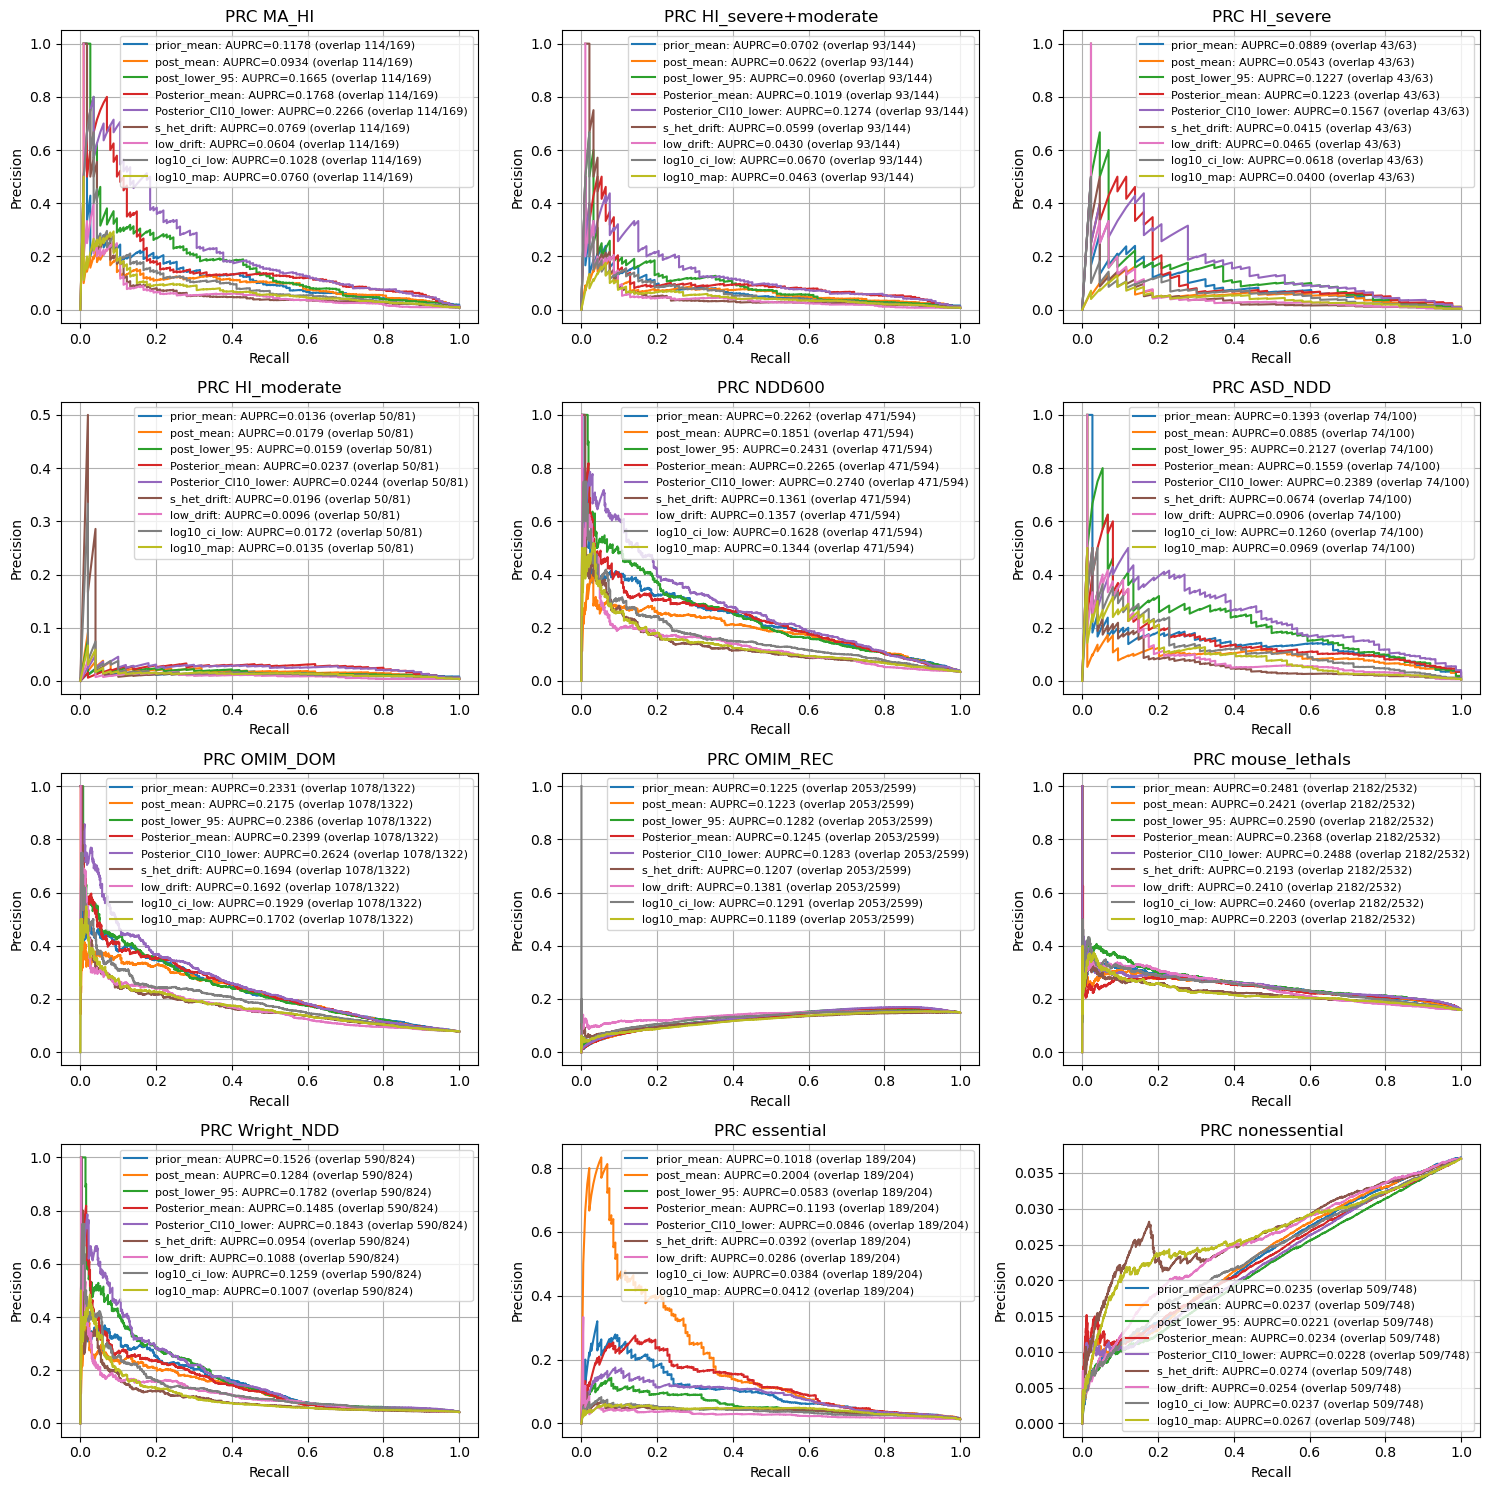

In [14]:
def precision_recall_ranked(ranked_ids, benchmark_ids):
    """
    ranked_ids: 1D array/list of ranked gene IDs (the universe)
    benchmark_ids: iterable of benchmark gene IDs (positives, may include IDs not in universe)

    Returns precision, recall computed on positives that are present in the universe.
    """
    ranked_ids = np.asarray(ranked_ids)
    bench = set(benchmark_ids)

    is_pos = np.fromiter((g in bench for g in ranked_ids), dtype=bool, count=len(ranked_ids))

    TP = np.cumsum(is_pos)
    FP = np.cumsum(~is_pos)

    # Only positives that can possibly be recovered
    P = is_pos.sum()
    if P == 0:
        # No overlap: undefined recall curve; return empty arrays (or zeros)
        return np.array([]), np.array([]), 0, 0

    FN = P - TP
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    return precision, recall, P, len(bench)

MA_genes = gene_lists['MacArthurHIgenes']
HI_severe_and_moserate = gene_lists['HI_severe_and_moderate']
df_HI_severe_genes = gene_lists['HI_severe']
df_HI_moderate_genes = gene_lists['HI_moderate']
NDD600 = gene_lists['NDD600']
df_ASD_NDD_genes = gene_lists['ASD_NDD']
df_OMIM_DOM_genes = gene_lists['OMIM_DOM']
df_OMIM_REC_genes = gene_lists['OMIM_REC']
df_mouse_lethals_genes = gene_lists['mouse_lethals']
Wright_NDD_genes = gene_lists['Wright_NDD']
df_essential_genes = gene_lists['CRISPR_essential']
df_nonessential_genes = gene_lists['CRISPR_nonessential']

def plot_benchmarks(df_sfac, df_labels, bench_arr, labs, filename=None):
    fig, axes = plt.subplots(4, 3, figsize=(15, 15))
    axes = axes.flatten()

    universe = df_sfac["gene_id"].to_numpy()

    for idx, bench in enumerate(bench_arr):
        for c in df_labels:
            df_sort = df_sfac.sort_values(by=c, ascending=False)
            ranked = df_sort["gene_id"].to_numpy()

            precision, recall, P_in_universe, P_total = precision_recall_ranked(ranked, bench)

            if precision.size == 0:
                axes[idx].plot([], [], label=f"{c}: no overlap (0/{P_total})")
                continue

            auc = np.trapezoid(precision, recall)
            axes[idx].plot(
                recall, precision,
                label=f"{c}: AUPRC={auc:.4f} (overlap {P_in_universe}/{P_total})"
            )

        axes[idx].set_xlabel("Recall")
        axes[idx].set_ylabel("Precision")
        axes[idx].set_title(f"PRC {labs[idx]}")
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True)

    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, dpi=200)
    plt.show()

labs = ["MA_HI", 
        "HI_severe+moderate", 
        "HI_severe", 
        "HI_moderate", 
        "NDD600", 
        "ASD_NDD", 
        "OMIM_DOM",
        "OMIM_REC",
        "mouse_lethals",
        "Wright_NDD",
        "essential",
        "nonessential"]

bench_arr = [MA_genes, 
             HI_severe_and_moserate,
             df_HI_severe_genes, 
             df_HI_moderate_genes, 
             NDD600, 
             df_ASD_NDD_genes, 
             df_OMIM_DOM_genes,
             df_OMIM_REC_genes,
             df_mouse_lethals_genes,
             Wright_NDD_genes,
             df_essential_genes,
             df_nonessential_genes]

df_labels = ["prior_mean",
             "post_mean",
             "post_lower_95",
             "Posterior_mean",
             "Posterior_CI10_lower",
             "s_het_drift", 
             "low_drift",
             "log10_ci_low", 
             "log10_map"
            ]


plot_benchmarks(df_summary, df_labels, bench_arr=bench_arr, labs=labs, filename=None)

In [13]:
# Analysis of PR curves

In [23]:
def TP_FP_FN(ranked_ids, benchmark_ids):
    """
    ranked_ids: 1D array/list of ranked gene IDs (the universe)
    benchmark_ids: iterable of benchmark gene IDs (positives, may include IDs not in universe)

    Returns precision, recall computed on positives that are present in the universe.
    """
    ranked_ids = np.asarray(ranked_ids)
    bench = set(benchmark_ids)

    is_pos = np.fromiter((g in bench for g in ranked_ids), dtype=bool, count=len(ranked_ids))

    TP = np.cumsum(is_pos)
    FP = np.cumsum(~is_pos)

    # Only positives that can possibly be recovered
    P = is_pos.sum()
    if P == 0:
        # No overlap: undefined recall curve; return empty arrays (or zeros)
        return np.array([]), np.array([]), 0, 0

    FN = P - TP
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    return TP, FP, FN, precision, recall


In [24]:
df_sort = df_summary.sort_values(by="Posterior_CI5_lower", ascending=False)
ranked = df_sort["gene_id"].to_numpy()
TP, FP, FN, precision, recall = TP_FP_FN(ranked, NDD600)
print(TP[0:40])
print(FP[0:40])
print(FN[0:40])
print(precision[0:40])
print(recall[0:40])

[ 0  1  2  3  4  4  4  5  6  7  8  9 10 11 11 12 13 14 14 14 15 16 17 18
 18 18 18 19 19 20 20 21 22 22 23 24 25 26 27 27]
[ 1  1  1  1  1  2  3  3  3  3  3  3  3  3  4  4  4  4  5  6  6  6  6  6
  7  8  9  9 10 10 11 11 11 12 12 12 12 12 12 13]
[471 470 469 468 467 467 467 466 465 464 463 462 461 460 460 459 458 457
 457 457 456 455 454 453 453 453 453 452 452 451 451 450 449 449 448 447
 446 445 444 444]
[0.         0.5        0.66666667 0.75       0.8        0.66666667
 0.57142857 0.625      0.66666667 0.7        0.72727273 0.75
 0.76923077 0.78571429 0.73333333 0.75       0.76470588 0.77777778
 0.73684211 0.7        0.71428571 0.72727273 0.73913043 0.75
 0.72       0.69230769 0.66666667 0.67857143 0.65517241 0.66666667
 0.64516129 0.65625    0.66666667 0.64705882 0.65714286 0.66666667
 0.67567568 0.68421053 0.69230769 0.675     ]
[0.         0.00212314 0.00424628 0.00636943 0.00849257 0.00849257
 0.00849257 0.01061571 0.01273885 0.014862   0.01698514 0.01910828
 0.02123142 0.023354

In [25]:
df_sort = df_summary.sort_values(by="post_lower_95", ascending=False)
ranked = df_sort["gene_id"].to_numpy()
TP, FP, FN, precision, recall = TP_FP_FN(ranked, NDD600)
print(TP[0:40])
print(FP[0:40])
print(FN[0:40])
print(precision[0:40])
print(recall[0:40])

[ 1  2  3  4  5  6  7  8  8  9  9  9 10 10 10 10 10 11 11 12 13 14 14 14
 15 16 17 17 17 17 17 18 18 19 19 19 19 19 20 20]
[ 0  0  0  0  0  0  0  0  1  1  2  3  3  4  5  6  7  7  8  8  8  8  9 10
 10 10 10 11 12 13 14 14 15 15 16 17 18 19 19 20]
[470 469 468 467 466 465 464 463 463 462 462 462 461 461 461 461 461 460
 460 459 458 457 457 457 456 455 454 454 454 454 454 453 453 452 452 452
 452 452 451 451]
[1.         1.         1.         1.         1.         1.
 1.         1.         0.88888889 0.9        0.81818182 0.75
 0.76923077 0.71428571 0.66666667 0.625      0.58823529 0.61111111
 0.57894737 0.6        0.61904762 0.63636364 0.60869565 0.58333333
 0.6        0.61538462 0.62962963 0.60714286 0.5862069  0.56666667
 0.5483871  0.5625     0.54545455 0.55882353 0.54285714 0.52777778
 0.51351351 0.5        0.51282051 0.5       ]
[0.00212314 0.00424628 0.00636943 0.00849257 0.01061571 0.01273885
 0.014862   0.01698514 0.01698514 0.01910828 0.01910828 0.01910828
 0.02123142 0.02123142

In [22]:
df_sort[0:20][["gene_id", "Posterior_CI5_lower", "gene_name"]]

,gene_id,Posterior_CI5_lower,gene_name
3988,ENSG00000114867,0.990814,EIF4G1
4928,ENSG00000123066,0.920297,MED13L
4403,ENSG00000118058,0.886943,KMT2A
9432,ENSG00000159140,0.854798,SON
10356,ENSG00000164190,0.765187,NIPBL
12248,ENSG00000173120,0.737455,KDM2A
2627,ENSG00000104517,0.710728,UBR5
8295,ENSG00000148143,0.636220,ZNF462
82,ENSG00000005339,0.636220,CREBBP
2031,ENSG00000100207,0.636220,TCF20


In [11]:
def early_precision_genes(rank1, rank2, positives):
    """
    rank1, rank2: ordered lists/arrays of gene_ids (best → worst)
    positives: set of true positives (e.g. NDD600)
    """
    positives = set(positives)
    rank2_set = set(rank2)

    # 1. Find cutoff where model1 precision drops below 1
    early_genes = []
    for g in rank1:
        if g in positives:
            early_genes.append(g)
        else:
            break   # precision < 1 from here

    early_genes = set(early_genes)

    # 2. Genes in early region of model1 but not retrieved early by model2
    # (i.e. not present anywhere in model2 ranking yet)
    missing_in_model2 = early_genes - rank2_set

    return early_genes, missing_in_model2


In [13]:
rank_model1 = df_summary.sort_values("post_lower_95", ascending=False)["gene_id"].values
rank_model2 = df_summary.sort_values("Posterior_CI5_lower", ascending=False)["gene_id"].values
positives = gene_lists["NDD600"]

early_m1, m1_not_m2 = early_precision_genes(rank_model1, rank_model2, positives)

print("Genes responsible for precision=1 region in model 1:")
print(sorted(early_m1))

print("\nGenes missing in model 2:")
print(sorted(m1_not_m2))


Genes responsible for precision=1 region in model 1:
['ENSG00000005339', 'ENSG00000083168', 'ENSG00000108510', 'ENSG00000118058', 'ENSG00000123066', 'ENSG00000125107', 'ENSG00000164190', 'ENSG00000187555']

Genes missing in model 2:
[]


In [7]:
df_summary.columns

Index(['gene_id', 'L_mean', 'L_median', 'L_mode', 'Posterior_mean',
       'Posterior_median', 'Posterior_mode', 'LL_CI10_lower', 'LL_CI10_upper',
       'Posterior_CI10_lower', 'Posterior_CI10_upper', 'LL_CI5_lower',
       'LL_CI5_upper', 'Posterior_CI5_lower', 'Posterior_CI5_upper',
       'gene_name', 'chrom', 'obs_lof', 'exp_lof', 'prior_mean', 'post_mean',
       'post_lower_95', 'post_upper_95'],
      dtype='object')

In [7]:
# Normalise to s scale in GeneBayes

In [7]:
from sklearn.isotonic import IsotonicRegression

def fit_log_isotonic_transform(
    df,
    x_col,
    y_col,
    mad_thresh=4.0,
):
    fit_df = df[[x_col, y_col]].dropna()
    fit_df = fit_df[(fit_df[x_col] > 0) & (fit_df[y_col] > 0)].copy()

    if len(fit_df) < 5:
        raise ValueError(f"Not enough valid rows to fit {x_col} -> {y_col}")

    x = np.log10(fit_df[x_col].to_numpy())
    y = np.log10(fit_df[y_col].to_numpy())

    # initial linear fit only for outlier removal
    coef = np.polyfit(x, y, 1)
    y_pred = np.polyval(coef, x)
    residuals = y - y_pred
    mad = np.median(np.abs(residuals - np.median(residuals)))

    if mad == 0:
        mask = np.ones_like(residuals, dtype=bool)
    else:
        mask = np.abs(residuals) < mad_thresh * mad

    x_clean = x[mask]
    y_clean = y[mask]

    order = np.argsort(x_clean)
    x_clean = x_clean[order]
    y_clean = y_clean[order]

    iso = IsotonicRegression(
        increasing=True,
        out_of_bounds="clip"
    )
    iso.fit(x_clean, y_clean)

    fit_info = {
        "n_total": len(x),
        "n_used": len(x_clean),
        "coef_linear": coef,
        "mad": mad,
        "x_clean": x_clean,
        "y_clean": y_clean,
    }
    return iso, fit_info


def apply_log_isotonic_transform(df, source_col, model, out_col):
    df[out_col] = np.nan
    mask = df[source_col].notna() & (df[source_col] > 0)
    x = np.log10(df.loc[mask, source_col].to_numpy())
    df.loc[mask, out_col] = 10 ** model.predict(x)
    return df

In [8]:
pairs = [
    ("Posterior_mean",      "post_mean",      "Posterior_mean_scaled_to_post"),
    ("Posterior_CI5_lower", "post_lower_95",  "Posterior_CI5_lower_scaled_to_post"),
    ("Posterior_CI5_upper", "post_upper_95",  "Posterior_CI5_upper_scaled_to_post"),
]

fit_results = {}

for x_col, y_col, out_col in pairs:
    model, info = fit_log_isotonic_transform(df_summary, x_col=x_col, y_col=y_col)
    df_summary = apply_log_isotonic_transform(df_summary, source_col=x_col, model=model, out_col=out_col)
    fit_results[(x_col, y_col)] = {"model": model, "info": info}

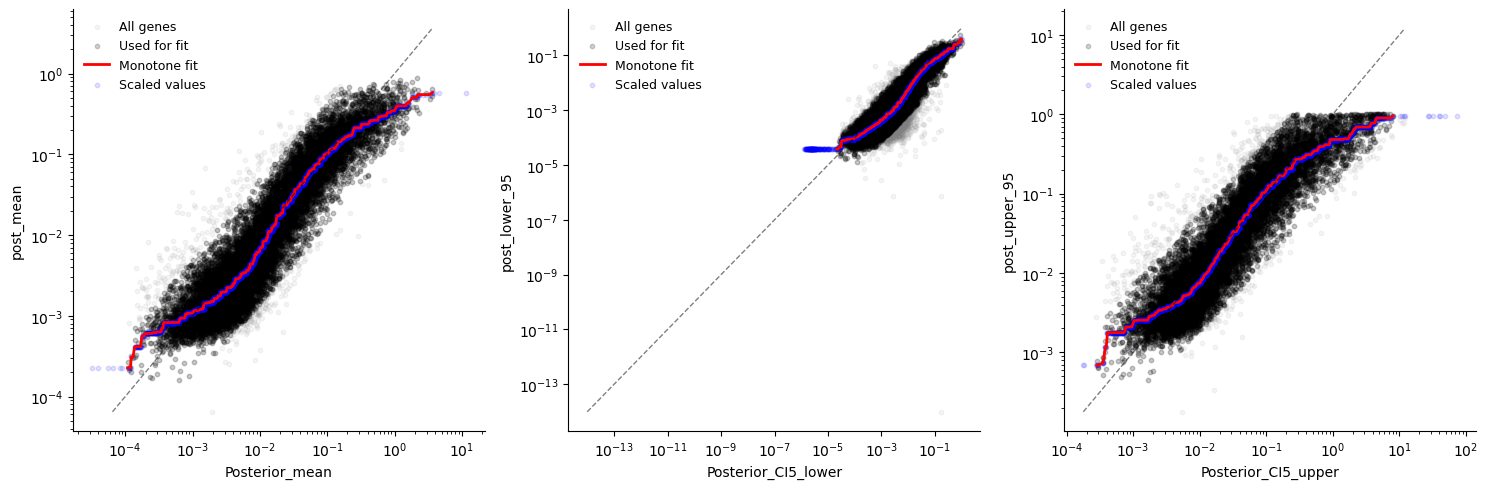

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (x_col, y_col, scaled_col) in zip(axes, pairs):
    model = fit_results[(x_col, y_col)]["model"]
    info = fit_results[(x_col, y_col)]["info"]

    fit_df = df_summary[[x_col, y_col]].dropna()
    fit_df = fit_df[(fit_df[x_col] > 0) & (fit_df[y_col] > 0)]

    x = fit_df[x_col].to_numpy()
    y = fit_df[y_col].to_numpy()

    ax.scatter(x, y, s=10, alpha=0.08, color="gray", label="All genes")

    x_clean = 10 ** info["x_clean"]
    y_clean = 10 ** info["y_clean"]
    ax.scatter(x_clean, y_clean, s=10, alpha=0.18, color="black", label="Used for fit")

    xg_log = np.linspace(info["x_clean"].min(), info["x_clean"].max(), 500)
    yg_log = model.predict(xg_log)
    ax.plot(10 ** xg_log, 10 ** yg_log, color="red", lw=2, label="Monotone fit")

    mask = df_summary[[x_col, scaled_col]].notna().all(axis=1)
    ax.scatter(
        df_summary.loc[mask, x_col],
        df_summary.loc[mask, scaled_col],
        s=10, alpha=0.12, color="blue", label="Scaled values"
    )

    xmin = min(np.nanmin(x), np.nanmin(y))
    xmax = max(np.nanmax(x), np.nanmax(y))
    ax.plot([xmin, xmax], [xmin, xmax], "k--", lw=1, alpha=0.5)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
mask_valid = df_summary[
    [
        "Posterior_CI5_lower_scaled_to_post",
        "Posterior_mean_scaled_to_post",
        "Posterior_CI5_upper_scaled_to_post"
    ]
].notna().all(axis=1)

df_check = df_summary.loc[mask_valid].copy()

violations = ~(
    (df_check["Posterior_CI5_lower_scaled_to_post"] <= df_check["Posterior_mean_scaled_to_post"]) &
    (df_check["Posterior_mean_scaled_to_post"] <= df_check["Posterior_CI5_upper_scaled_to_post"])
)

print(f"Number of violations: {violations.sum()} / {len(df_check)}")

Number of violations: 1 / 17052


In [15]:
df_bad = df_check.loc[violations, [
    "gene_id", "Posterior_mean", "Posterior_CI5_lower", "Posterior_CI5_upper",
    "Posterior_CI5_lower_scaled_to_post",
    "Posterior_mean_scaled_to_post",
    "Posterior_CI5_upper_scaled_to_post"
]]

print(df_bad.head())

               gene_id  Posterior_mean  Posterior_CI5_lower  \
16887  ENSG00000272804        0.029169             0.000002   

       Posterior_CI5_upper  Posterior_CI5_lower_scaled_to_post  \
16887             0.024705                            0.000038   

       Posterior_mean_scaled_to_post  Posterior_CI5_upper_scaled_to_post  
16887                       0.029135                            0.023222  


In [16]:
df_summary.columns

Index(['gene_id', 'L_mean', 'L_median', 'L_mode', 'Posterior_mean',
       'Posterior_median', 'Posterior_mode', 'LL_CI10_lower', 'LL_CI10_upper',
       'Posterior_CI10_lower', 'Posterior_CI10_upper', 'LL_CI5_lower',
       'LL_CI5_upper', 'Posterior_CI5_lower', 'Posterior_CI5_upper',
       'gene_name', 'chrom', 'obs_lof', 'exp_lof', 'prior_mean', 'post_mean',
       'post_lower_95', 'post_upper_95', 'Posterior_mean_scaled_to_post',
       'Posterior_CI5_lower_scaled_to_post',
       'Posterior_CI5_upper_scaled_to_post'],
      dtype='object')

In [18]:
df_summary = df_summary.rename(columns={'Posterior_mean_scaled_to_post': 'Post_mean', 
                                        'Posterior_CI5_lower_scaled_to_post': 'Post_95_lower',
                                        'Posterior_CI5_upper_scaled_to_post': 'Post_95_upper'})

In [19]:
df_summary[['gene_id', 'gene_name', 'Post_mean', 'Post_95_lower', 'Post_95_upper']].to_csv("../../../Clonal_Expansion_Misha/Grants/data/LoF_s_het.txt", sep="\t", index=False)